In [ ]:
import pandas as pd

# llama-3.3-70B.csv
MODEL_IDS = ["qwen-3.5-27B", "llama-3.3-70B", "gemma-4-31B"]#, "gpt-5.5"]
MEASURES = [("humt", "Human Likeness"), ("sociot_status", "Status"), ("sociot_social_distance", "Social Distance"), ("sociot_gender", "Gender"), ("sociot_warmth", "Warmth")]

In [6]:
# merge results
dfs = []
for model_id in MODEL_IDS:
    # /mnt/homes/marlene/SEAL/seal/evaluation/human_likeness/humtdumt/results/sampled_dataset_responses_clean_responses_gemma-4-31B.csv
    path = f"/mnt/homes/marlene/SEAL/seal/evaluation/human_likeness/humtdumt/results/sampled_dataset_responses_clean_responses_{model_id}.csv"
    df = pd.read_csv(path, index_col=None).set_index("id")
    dfs.append(df)

merged = pd.concat(dfs, axis=1)
merged = merged.loc[:, ~merged.columns.duplicated()]

merged.to_csv("human_likeness_all_models.csv", index="id")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/homes/marlene/SEAL/seal/evaluation/human_likeness/humtdumt/results/sampled_dataset_responses_clean_responses_llama-3.3-70B.csv'

In [ ]:
res = {} 

for model_id in MODEL_IDS: 
    path = f"/mnt/homes/marlene/SEAL/seal/evaluation/human_likeness/Elisa_prompts_sample_responses_{model_id}_response_humt_sociot_status_sociot_social_distance_sociot_gender_sociot_warmth.csv" 
    res[model_id] = pd.read_csv(path, index_col="id")

In [ ]:

# print mean per ses category

for model_id, df in merged.items():
    print(model_id)

    # groups users  according to ses
    df["ses_bucket"] = pd.cut(
        df["ses"],
        bins=[0, 3, 7, 10],
        labels=["low", "medium", "high"],
        include_lowest=True
    )

    # Print means for each SES bucket
    for measure,_ in MEASURES:
        print(f"\n{measure}")
        col = f"{measure}_{model_id}_response"
        print(df.groupby("ses_bucket", observed=True)[col].mean().round(3))

    print()

qwen_3.5_27B

humt
ses_bucket
low       0.019
medium    0.015
high      0.006
Name: humt_qwen_3.5_27B_response, dtype: float64

sociot_status
ses_bucket
low      -0.052
medium   -0.060
high     -0.055
Name: sociot_status_qwen_3.5_27B_response, dtype: float64

sociot_social_distance
ses_bucket
low       0.038
medium    0.035
high      0.026
Name: sociot_social_distance_qwen_3.5_27B_response, dtype: float64

sociot_gender
ses_bucket
low       0.004
medium    0.006
high     -0.007
Name: sociot_gender_qwen_3.5_27B_response, dtype: float64

sociot_warmth
ses_bucket
low       0.019
medium    0.015
high      0.007
Name: sociot_warmth_qwen_3.5_27B_response, dtype: float64

llama_3.3_70B

humt
ses_bucket
low       0.020
medium    0.026
high      0.014
Name: humt_llama_3.3_70B_response, dtype: float64

sociot_status
ses_bucket
low      -0.064
medium   -0.060
high     -0.055
Name: sociot_status_llama_3.3_70B_response, dtype: float64

sociot_social_distance
ses_bucket
low       0.036
medium    0.0

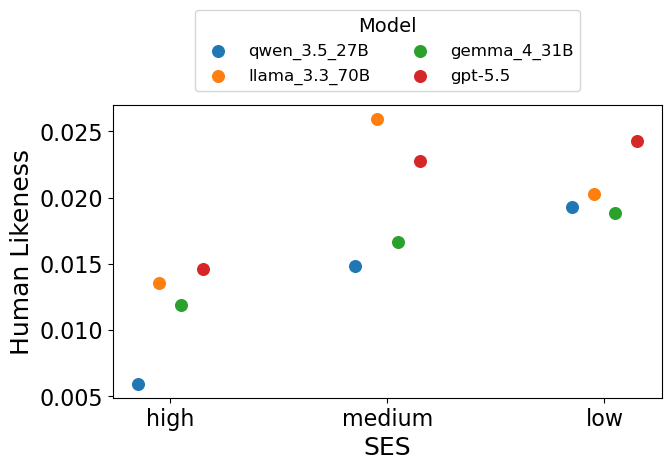

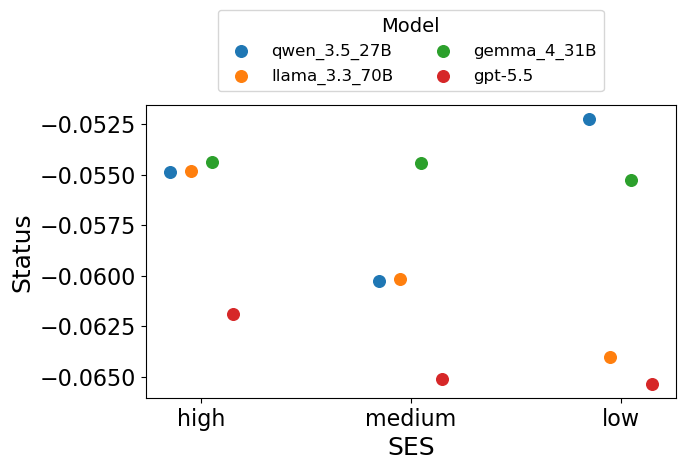

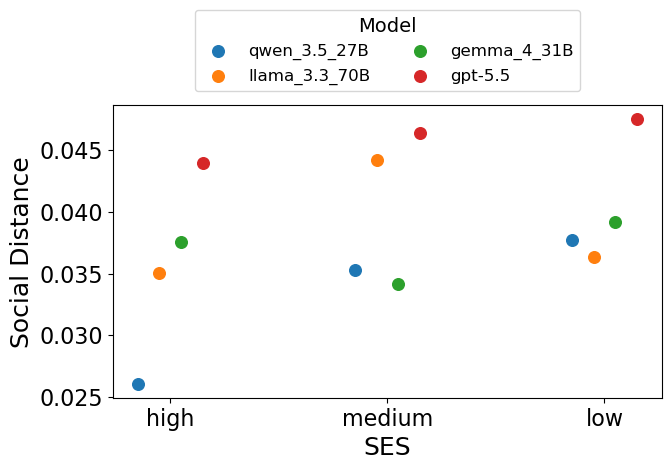

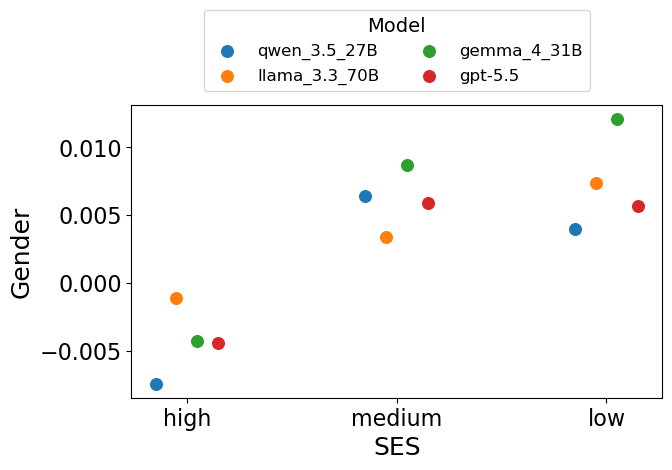

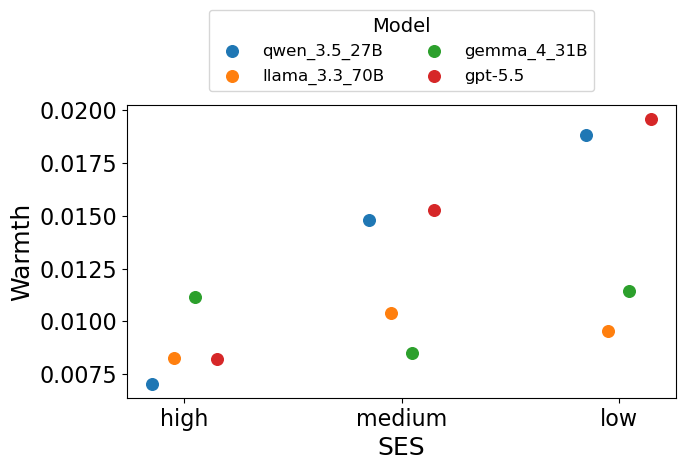

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.size": 16,          # default font size
    "axes.titlesize": 20,     # plot title
    "axes.labelsize": 18,     # x/y axis labels
    "xtick.labelsize": 16,    # x-axis tick labels
    "ytick.labelsize": 16,    # y-axis tick labels
    "legend.fontsize": 12,    # legend text
    "legend.title_fontsize": 14
})

ses_order = ["high", "medium", "low"]

for measure, m_name in MEASURES:

    plot_data = []

    for model_id, df in merged.items():

        df = df.copy()
        col = f"{measure}_{model_id}_response"

        df["ses_bucket"] = pd.cut(
            df["ses"],
            bins=[0, 3, 7, 10],
            labels=["low", "medium", "high"],
            include_lowest=True
        )

        means = (
            df.groupby("ses_bucket", observed=True)[col]
            .mean()
            .reindex(ses_order)
        )

        for ses, value in means.items():
            plot_data.append({
                "model": model_id,
                "ses_bucket": ses,
                "mean": value
            })

    plot_df = pd.DataFrame(plot_data)

    # ---- plot ----
    models = plot_df["model"].unique()

    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(ses_order))
    dodge_width = 0.4 / len(models)

    for i, model in enumerate(models):
        model_df = plot_df[plot_df["model"] == model]

        xpos = x + (i - len(models) / 2) * dodge_width + dodge_width / 2

        values = [
            model_df.loc[
                model_df["ses_bucket"] == ses, "mean"
            ].values[0]
            for ses in ses_order
        ]

        ax.scatter(
            xpos,
            values,
            s=70,
            marker="o",
            label=model
        )

    ax.set_xticks(x)
    ax.set_xticklabels(ses_order)

    ax.set_xlabel("SES")
    ax.set_ylabel(m_name)

    ax.legend(
    title="Model",
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
)

    plt.tight_layout()
    plt.show()

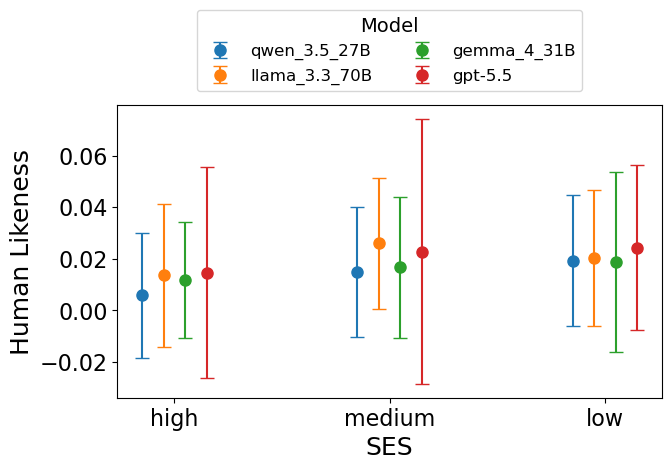

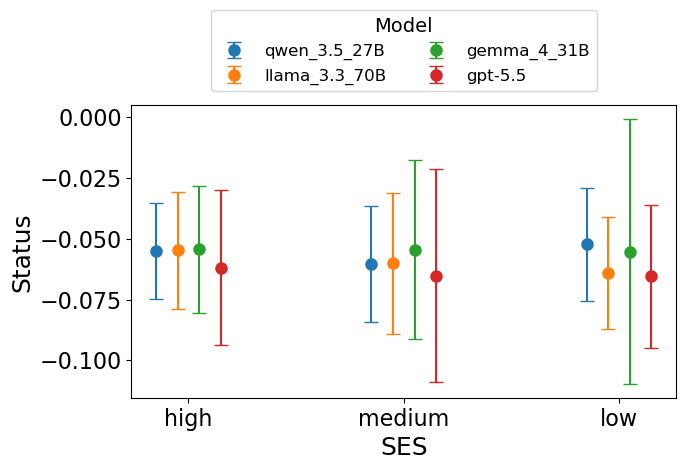

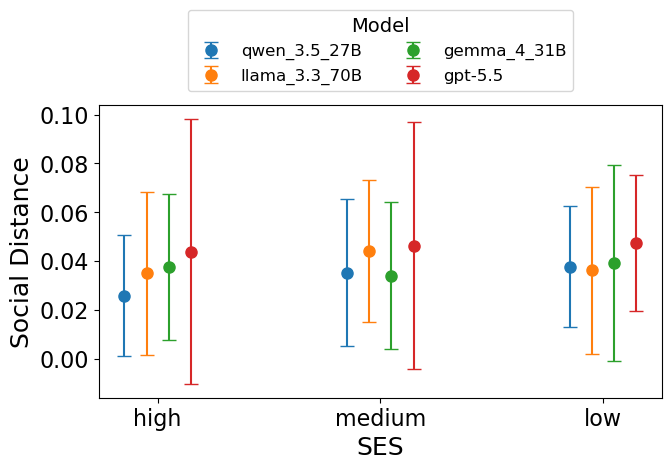

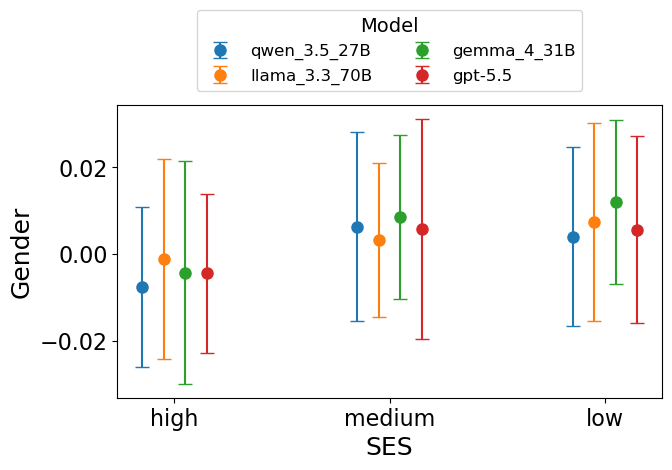

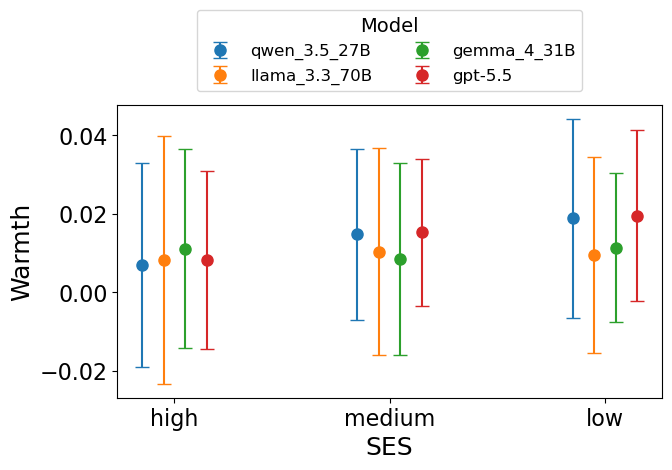

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14
})

ses_order = ["high", "medium", "low"]

for measure, m_name in MEASURES:

    plot_data = []

    for model_id, df in merged.items():

        df = df.copy()
        col = f"{measure}_{model_id}_response"

        df["ses_bucket"] = pd.cut(
            df["ses"],
            bins=[0, 3, 7, 10],
            labels=["low", "medium", "high"],
            include_lowest=True
        )

        stats = (
            df.groupby("ses_bucket", observed=True)[col]
            .agg(["mean", "std"])
            .reindex(ses_order)
        )

        for ses, row in stats.iterrows():
            plot_data.append({
                "model": model_id,
                "ses_bucket": ses,
                "mean": row["mean"],
                "std": row["std"]
            })

    plot_df = pd.DataFrame(plot_data)

    models = plot_df["model"].unique()

    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(ses_order))
    dodge_width = 0.4 / len(models)

    for i, model in enumerate(models):
        model_df = plot_df[plot_df["model"] == model]

        xpos = x + (i - len(models) / 2) * dodge_width + dodge_width / 2

        values = [
            model_df.loc[
                model_df["ses_bucket"] == ses, "mean"
            ].values[0]
            for ses in ses_order
        ]

        errors = [
            model_df.loc[
                model_df["ses_bucket"] == ses, "std"
            ].values[0]
            for ses in ses_order
        ]

        ax.errorbar(
            xpos,
            values,
            yerr=errors,
            fmt="o",
            markersize=8,
            capsize=5,
            label=model
        )

    ax.set_xticks(x)
    ax.set_xticklabels(ses_order)

    ax.set_xlabel("SES")
    ax.set_ylabel(m_name)

    ax.legend(
        title="Model",
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
    )

    plt.tight_layout()
    plt.show()